In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

In [ ]:
df = pd.read_excel("Customer_chrun_dataset.xlsx")


df.drop(columns=["Customer_ID"], inplace=True)

leak_cols = ["Customer_Status", "Churn_Category", "Churn_Reason"]
df.drop(columns=leak_cols, inplace=True)

In [ ]:
df["Avg_Monthly_Revenue"] = df["Total_Revenue"] / (df["Tenure_in_Months"] + 1)
df["High_Value_Customer"] = (
    df["Total_Revenue"] > df["Total_Revenue"].median()
).astype(int)


y = df["churn status"]
X = df.drop(columns=["churn status"])

cat_cols = X.select_dtypes(include="object").columns.tolist()
num_cols = X.select_dtypes(exclude="object").columns.tolist()

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols)
    ]
)

In [ ]:
pipeline = Pipeline(steps=[
    ("prep", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=12,
        random_state=42,
        class_weight="balanced"
    ))
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

pipeline.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Age', 'Number_of_Referrals',
                                                   'Tenure_in_Months',
                                                   'Monthly_Charge',
                                                   'Total_Charges',
                                                   'Total_Refunds',
                                                   'Total_Extra_Data_Charges',
                                                   'Total_Long_Distance_Charges',
                                                   'Total_Revenue',
                                                   'Avg_Monthly_Revenue',
                                                   'High_Value_Customer']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_ou...
                                                   'Internet_Service',
                                                   'Internet_Type',
                                                   'Online_Security',
                                                   'Online_Backup',
                                                   'Device_Protection_Plan',
                                                   'Premium_Support',
                                                   'Streaming_TV',
                                                   'Streaming_Movies',
                                                   'Streaming_Music',
                                                   'Unlimited_Data', 'Contract',
                                                   'Paperless_Billing',
                                                   'Payment_Method',
                                                   'Monthly Charge Status'])])),
                ('model',
                 RandomForestClassifier(class_weight='balanced', max_depth=12,
                                        n_estimators=300, random_state=42))])

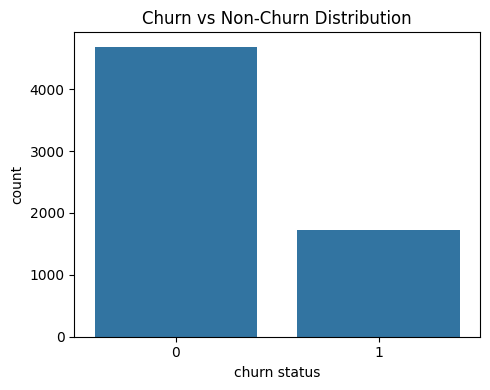

In [ ]:
plt.figure(figsize=(5,4))
sns.countplot(x=y)
plt.title("Churn vs Non-Churn Distribution")
plt.tight_layout()
plt.show()


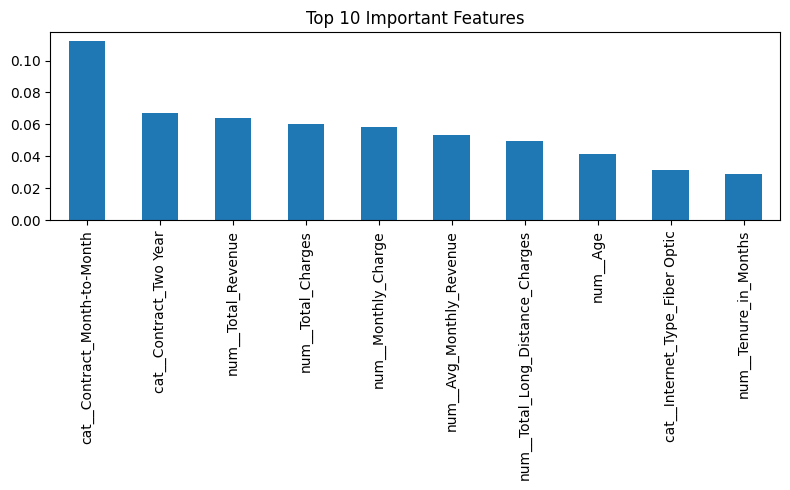

In [ ]:
feature_names = pipeline.named_steps["prep"].get_feature_names_out()
importances = pipeline.named_steps["model"].feature_importances_

feat_imp = (
    pd.Series(importances, index=feature_names)
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(8,5))
feat_imp.plot(kind="bar")
plt.title("Top 10 Important Features")
plt.tight_layout()
plt.show()


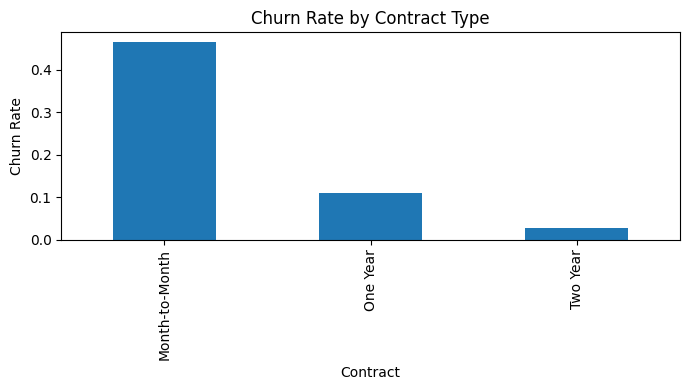

In [ ]:
contract_churn = (
    df.groupby("Contract")["churn status"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(7,4))
contract_churn.plot(kind="bar")
plt.ylabel("Churn Rate")
plt.title("Churn Rate by Contract Type")
plt.tight_layout()
plt.show()

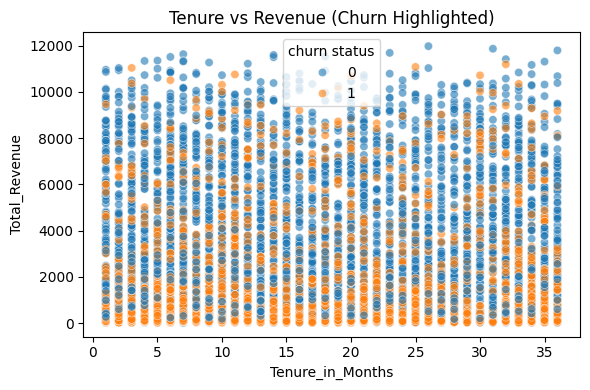

In [ ]:
plt.figure(figsize=(6,4))
sns.scatterplot(
    data=df,
    x="Tenure_in_Months",
    y="Total_Revenue",
    hue="churn status",
    alpha=0.6
)
plt.title("Tenure vs Revenue (Churn Highlighted)")
plt.tight_layout()
plt.show()

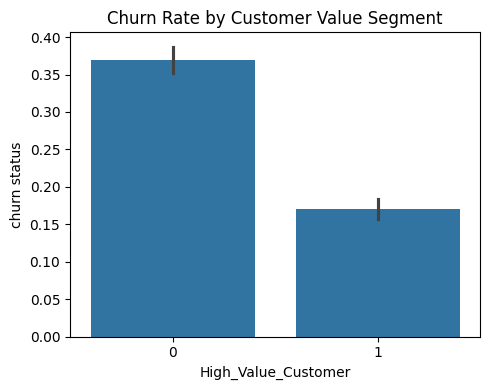

In [ ]:
plt.figure(figsize=(5,4))
sns.barplot(
    data=df,
    x="High_Value_Customer",
    y="churn status"
)
plt.title("Churn Rate by Customer Value Segment")
plt.tight_layout()
plt.show()

In [ ]:
contract_agg = df.groupby("Contract").agg(
    Churn_Rate=("churn status", "mean"),
    Avg_Revenue=("Total_Revenue", "mean")
)

internet_agg = df.groupby("Internet_Service").agg(
    Churn_Rate=("churn status", "mean"),
    Avg_Tenure=("Tenure_in_Months", "mean"),
    Avg_Revenue=("Total_Revenue", "mean")
)

payment_agg = df.groupby("Payment_Method").agg(
    Churn_Rate=("churn status", "mean"),
    Avg_Revenue=("Total_Revenue", "mean")
)

value_agg = df.groupby("High_Value_Customer").agg(
    Churn_Rate=("churn status", "mean"),
    Avg_Revenue=("Total_Revenue", "mean"),
    Avg_Tenure=("Tenure_in_Months", "mean")
)

In [ ]:
print("\n AGGREGATE: CONTRACT TYPE \n")
print(contract_agg)


 AGGREGATE: CONTRACT TYPE 

                Churn_Rate  Avg_Revenue
Contract                               
Month-to-Month    0.465307  1707.169114
One Year          0.110403  3977.404343
Two Year          0.027341  4794.392296


In [ ]:
print("\n AGGREGATE: INTERNET SERVICE \n")
print(internet_agg)



 AGGREGATE: INTERNET SERVICE 

                  Churn_Rate  Avg_Tenure  Avg_Revenue
Internet_Service                                     
No                  0.078417   17.423741  1437.930689
Yes                 0.322792   17.320406  3475.072940


In [ ]:
print("\n AGGREGATE: PAYMENT METHOD \n")
print(payment_agg)



 AGGREGATE: PAYMENT METHOD 

                 Churn_Rate  Avg_Revenue
Payment_Method                          
Bank Withdrawal    0.344336  3245.215791
Credit Card        0.147955  2965.253752
Mailed Check       0.378223  1359.315446


In [ ]:
print("\n AGGREGATE: CUSTOMER VALUE SEGMENT \n")
print(value_agg)


 AGGREGATE: CUSTOMER VALUE SEGMENT 

                     Churn_Rate  Avg_Revenue  Avg_Tenure
High_Value_Customer                                     
0                      0.369897   755.813815   17.301340
1                      0.169835  5311.930156   17.384232


In [ ]:
y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:, 1]

print("\n CLASSIFICATION REPORT \n")
print(classification_report(y_test, y_pred))

print("ROC-AUC SCORE:", roc_auc_score(y_test, y_prob))


 CLASSIFICATION REPORT 

              precision    recall  f1-score   support

           0       0.89      0.86      0.87       937
           1       0.65      0.71      0.68       347

    accuracy                           0.82      1284
   macro avg       0.77      0.78      0.78      1284
weighted avg       0.82      0.82      0.82      1284

ROC-AUC SCORE: 0.8776677051968542


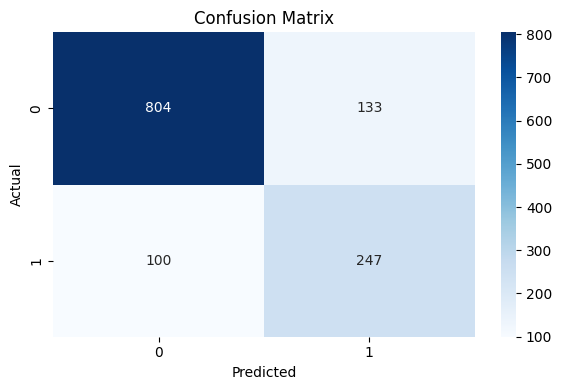

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


In [ ]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print("MODEL ACCURACY:", round(accuracy, 4))

MODEL ACCURACY: 0.8185
